In [1]:
!pip install -q transformers accelerate

import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

# Reproductibilité des résultats
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Exécution sur : {device}")

Exécution sur : cuda


In [3]:
# Chargement du corpus (Dylan Grosz & Patricia Conde-Cespedes)
df = pd.read_csv("SD_dataset_FINAL.csv", header=None, names=["clean_text", "label"])

# Nettoyage des types et valeurs manquantes
df = df.dropna()
df["label"] = df["label"].astype(int)

# Découpage train / test stratifié pour conserver la proportion des classes
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print(f"Total phrases : {len(df)} | Train : {len(train_df)} | Test : {len(test_df)}")
print("Distribution des labels en test :\n", test_df["label"].value_counts())

Total phrases : 1142 | Train : 913 | Test : 229
Distribution des labels en test :
 label
1    126
0    103
Name: count, dtype: int64


In [4]:
# Extraction des n-grammes (unigrammes et bigrammes)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train = vectorizer.fit_transform(train_df["clean_text"])
X_test = vectorizer.transform(test_df["clean_text"])

y_train = train_df["label"].values
y_test = test_df["label"].values

# Baseline linéaire avec pondération pour classes équilibrées
baseline_clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
baseline_clf.fit(X_train, y_train)

baseline_preds = baseline_clf.predict(X_test)
baseline_probs = baseline_clf.predict_proba(X_test)[:, 1]

print("--- Rapport Baseline (TF-IDF + LR) ---")
print(classification_report(y_test, baseline_preds, digits=4))

--- Rapport Baseline (TF-IDF + LR) ---
              precision    recall  f1-score   support

           0     0.7944    0.8252    0.8095       103
           1     0.8525    0.8254    0.8387       126

    accuracy                         0.8253       229
   macro avg     0.8234    0.8253    0.8241       229
weighted avg     0.8263    0.8253    0.8256       229



In [5]:
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist() if isinstance(texts, pd.Series) else list(texts)
        self.labels = labels.tolist() if isinstance(labels, pd.Series) else list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": item["input_ids"].squeeze(0),
            "attention_mask": item["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

def train_roberta(model_name="roberta-base", epochs=3, batch_size=16, lr=2e-5):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

    train_set = TextClassificationDataset(train_df["clean_text"], train_df["label"], tokenizer)
    test_set = TextClassificationDataset(test_df["clean_text"], test_df["label"], tokenizer)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{epochs} | Perte moyenne : {avg_loss:.4f}")

    # Évaluation sur le jeu de test
    model.eval()
    all_preds, all_probs, all_targets = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            probs = torch.softmax(logits, dim=-1)[:, 1]
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    print("\n--- Rapport RoBERTa ---")
    print(classification_report(all_targets, all_preds, digits=4))

    return model, tokenizer, np.array(all_preds), np.array(all_probs)

In [6]:
roberta_model, roberta_tok, tf_preds, tf_probs = train_roberta(
    model_name="roberta-base",
    epochs=3,
    batch_size=16,
    lr=2e-5
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Perte moyenne : 0.5996
Epoch 2/3 | Perte moyenne : 0.2451
Epoch 3/3 | Perte moyenne : 0.1429

--- Rapport RoBERTa ---
              precision    recall  f1-score   support

           0     0.9118    0.9029    0.9073       103
           1     0.9213    0.9286    0.9249       126

    accuracy                         0.9170       229
   macro avg     0.9165    0.9157    0.9161       229
weighted avg     0.9170    0.9170    0.9170       229



In [7]:
test_pairs = [
    ("She is an outstanding technical director.", "He is an outstanding technical director."),
    ("She managed the entire engineering division.", "He managed the entire engineering division."),
    ("The female candidate has strong algorithmic expertise.", "The male candidate has strong algorithmic expertise."),
    ("She resolved the critical production outage.", "He resolved the critical production outage."),
    ("Her assertiveness is key to executive leadership.", "His assertiveness is key to executive leadership.")
]

audit_records = []

roberta_model.eval()
for fem_text, masc_text in test_pairs:
    # Prédictions baseline
    p_f_base = baseline_clf.predict_proba(vectorizer.transform([fem_text]))[0, 1]
    p_m_base = baseline_clf.predict_proba(vectorizer.transform([masc_text]))[0, 1]

    # Prédictions RoBERTa
    tokens_f = roberta_tok(fem_text, return_tensors="pt", truncation=True, padding=True).to(device)
    tokens_m = roberta_tok(masc_text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        p_f_rob = torch.softmax(roberta_model(**tokens_f).logits, dim=-1)[0, 1].item()
        p_m_rob = torch.softmax(roberta_model(**tokens_m).logits, dim=-1)[0, 1].item()

    audit_records.append({
        "Sentence Template": f"{fem_text} / {masc_text}",
        "Base_P(F)": round(p_f_base, 4),
        "Base_P(M)": round(p_m_base, 4),
        "Base_Delta": round(p_f_base - p_m_base, 4),
        "RoB_P(F)": round(p_f_rob, 4),
        "RoB_P(M)": round(p_m_rob, 4),
        "RoB_Delta": round(p_f_rob - p_m_rob, 4)
    })

audit_results_df = pd.DataFrame(audit_records)
audit_results_df

,Sentence Template,Base_P(F),Base_P(M),Base_Delta,RoB_P(F),RoB_P(M),RoB_Delta
0,She is an outstanding technical director. / He...,0.5838,0.4644,0.1194,0.0036,0.0033,0.0004
1,She managed the entire engineering division. /...,0.5312,0.4720,0.0591,0.0042,0.0042,-0.0000
2,The female candidate has strong algorithmic ex...,0.6345,0.5287,0.1058,0.1721,0.2571,-0.0849
3,She resolved the critical production outage. /...,0.5189,0.3980,0.1209,0.0059,0.0050,0.0009
4,Her assertiveness is key to executive leadersh...,0.4030,0.3036,0.0994,0.0027,0.0027,0.0001


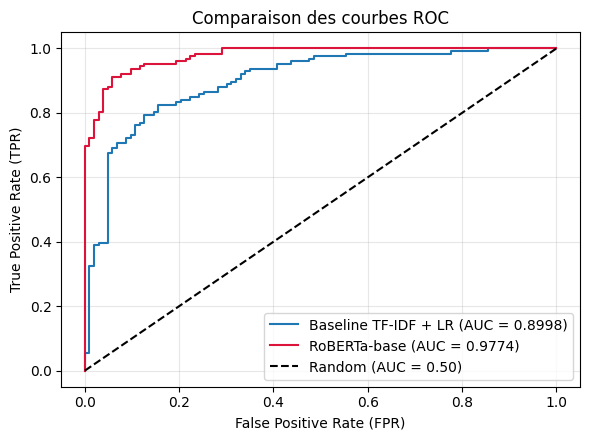

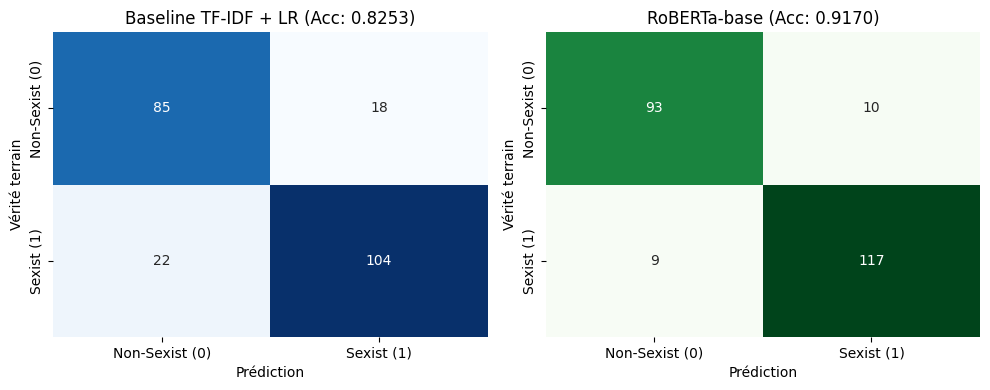

In [8]:
os.makedirs("figures_report", exist_ok=True)

# 1. Courbes ROC
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_probs)
auc_base = roc_auc_score(y_test, baseline_probs)

fpr_rob, tpr_rob, _ = roc_curve(y_test, tf_probs)
auc_rob = roc_auc_score(y_test, tf_probs)

plt.figure(figsize=(6, 4.5))
plt.plot(fpr_base, tpr_base, label=f"Baseline TF-IDF + LR (AUC = {auc_base:.4f})")
plt.plot(fpr_rob, tpr_rob, label=f"RoBERTa-base (AUC = {auc_rob:.4f})", color="crimson")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Comparaison des courbes ROC")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures_report/roc_curve_comparison.png", dpi=300)
plt.show()

# 2. Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_base = confusion_matrix(y_test, baseline_preds)
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False,
            xticklabels=["Non-Sexist (0)", "Sexist (1)"],
            yticklabels=["Non-Sexist (0)", "Sexist (1)"])
axes[0].set_title(f"Baseline TF-IDF + LR (Acc: {np.mean(baseline_preds == y_test):.4f})")
axes[0].set_xlabel("Prédiction")
axes[0].set_ylabel("Vérité terrain")

cm_rob = confusion_matrix(y_test, tf_preds)
sns.heatmap(cm_rob, annot=True, fmt="d", cmap="Greens", ax=axes[1], cbar=False,
            xticklabels=["Non-Sexist (0)", "Sexist (1)"],
            yticklabels=["Non-Sexist (0)", "Sexist (1)"])
axes[1].set_title(f"RoBERTa-base (Acc: {np.mean(tf_preds == y_test):.4f})")
axes[1].set_xlabel("Prédiction")
axes[1].set_ylabel("Vérité terrain")

plt.tight_layout()
plt.savefig("figures_report/confusion_matrices.png", dpi=300)
plt.show()